HEALTH GUARD AI DRIVEN MODEL

In [90]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns


In [91]:
import warnings
warnings.filterwarnings("ignore")

In [92]:
df= pd.read_csv("../data/diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


# EDA


In [93]:
df.shape

(768, 9)

In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [95]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


HERE , i Get To Know That Feature Like Glucose , Bloodpressure etc contain Minimun 0 Which Is Not Possible , But In reality Its a null Or empty Value

In [96]:
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

# VISUALIZATION

1

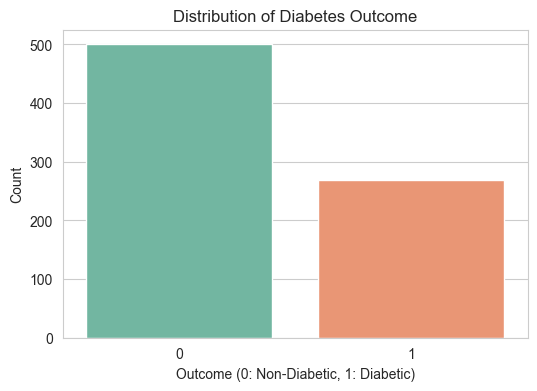

In [97]:
plt.figure(figsize=(6,4))
sns.countplot(x='Outcome',data=df,palette='Set2')

plt.title('Distribution of Diabetes Outcome')
plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.ylabel('Count')
plt.show()

2

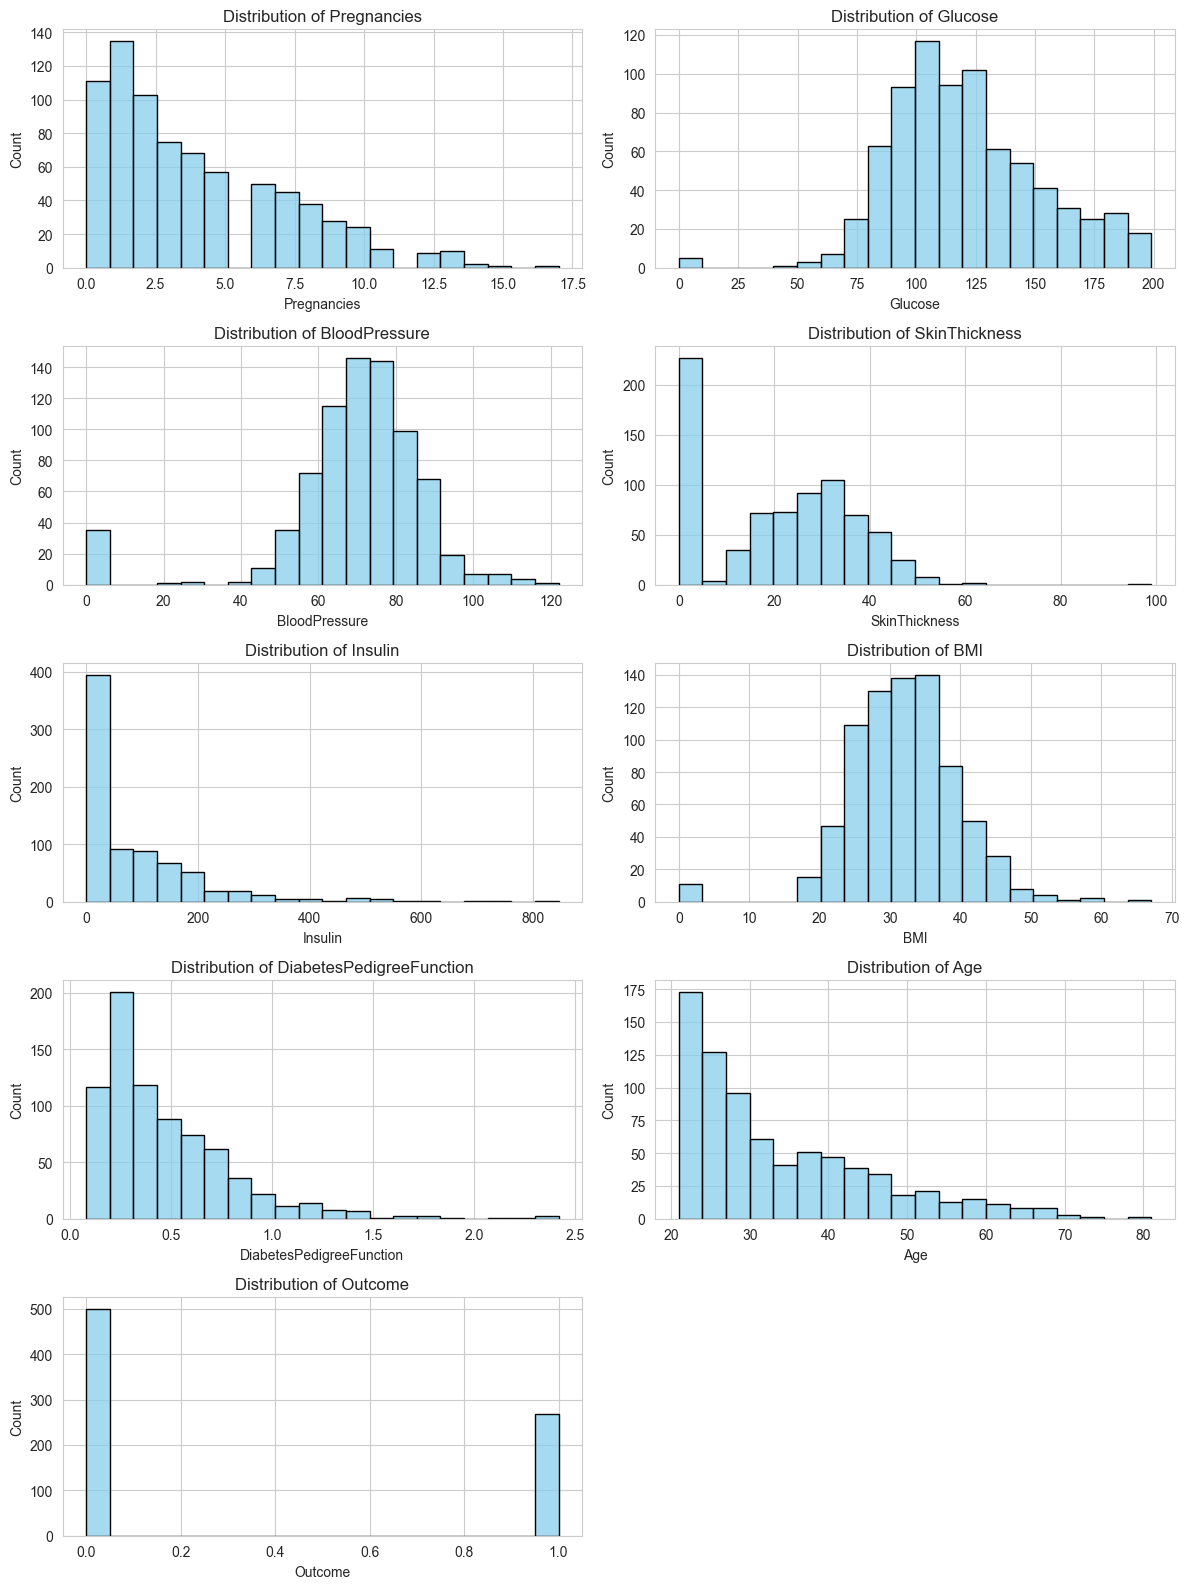

In [98]:
# 1. Set the visual style for our charts
sns.set_style("whitegrid")

# 2. Set up a massive blank canvas
plt.figure(figsize=(12, 16))

# 3. Loop through every column name in the dataset
for i, col in enumerate(df.columns, 1): # enumerate(..., 1) makes 'i' start at 1
    # Create a subplot: 5 rows, 2 columns, position 'i'
    plt.subplot(5, 2, i) 
    
    # Draw the seaborn plot in the current subplot slot
    sns.histplot(x=col, data=df, bins=20, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {col}') # Add a title to each small chart

# 4. Clean up the padding and show the final result once!
plt.tight_layout()
plt.show()


What to look for when this prints:

-> Normal Distributions (Bell Curves): Notice if any columns like BloodPressure or BMI look like a bell curve. This is good for ML!

-> Skewed Distributions: Notice if Age or Pregnancies are heavily weighted to the left side and tail off to the right. This means most people in the dataset are young or have few pregnancies.

-> Those sneaky zeros: Look at the chart for Insulin and SkinThickness. See that massive bar at 0? This graph visually confirms why we needed to check for zeros earlier!

3

In [99]:
df.corr()['Outcome']

Pregnancies                 0.221898
Glucose                     0.466581
BloodPressure               0.065068
SkinThickness               0.074752
Insulin                     0.130548
BMI                         0.292695
DiabetesPedigreeFunction    0.173844
Age                         0.238356
Outcome                     1.000000
Name: Outcome, dtype: float64

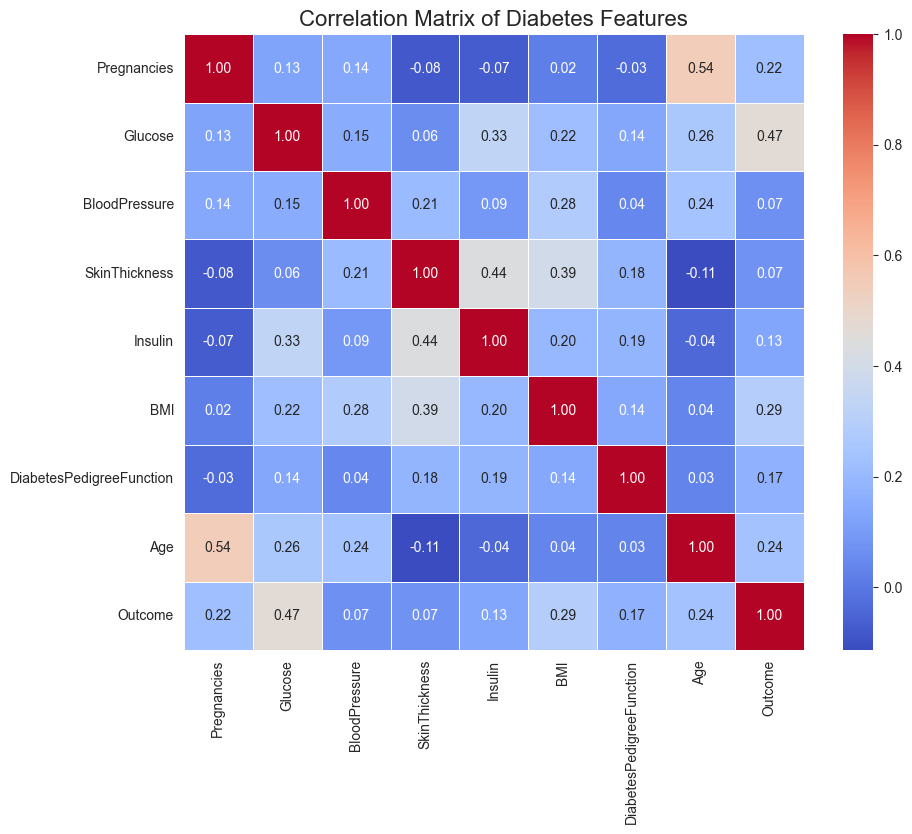

In [100]:
# calculate the correlation
corr_matrix = df.corr()
plt.figure(figsize=(10,8))

sns.heatmap(corr_matrix , annot = True # SHOW ACTUAL NUMBER INSIDE BLOCLS
, cmap = 'coolwarm' # color map ( blure for cold /low , red for hot/high))
,fmt = ".2f"# Format number to 2 decimal
,linewidth = 0.5 # add little white space b/w boxes 
)

plt.title('Correlation Matrix of Diabetes Features', fontsize=16)
# 5. Show the plot
plt.show()

1.0: Perfect positive correlation (As feature A goes up, feature B goes up exactly as much).

-1.0: Perfect negative correlation (As A goes up, B goes down).

0.0: Absolutely no mathematical relationship at all.

4
 Visualizing Outliers (Boxplots)
 

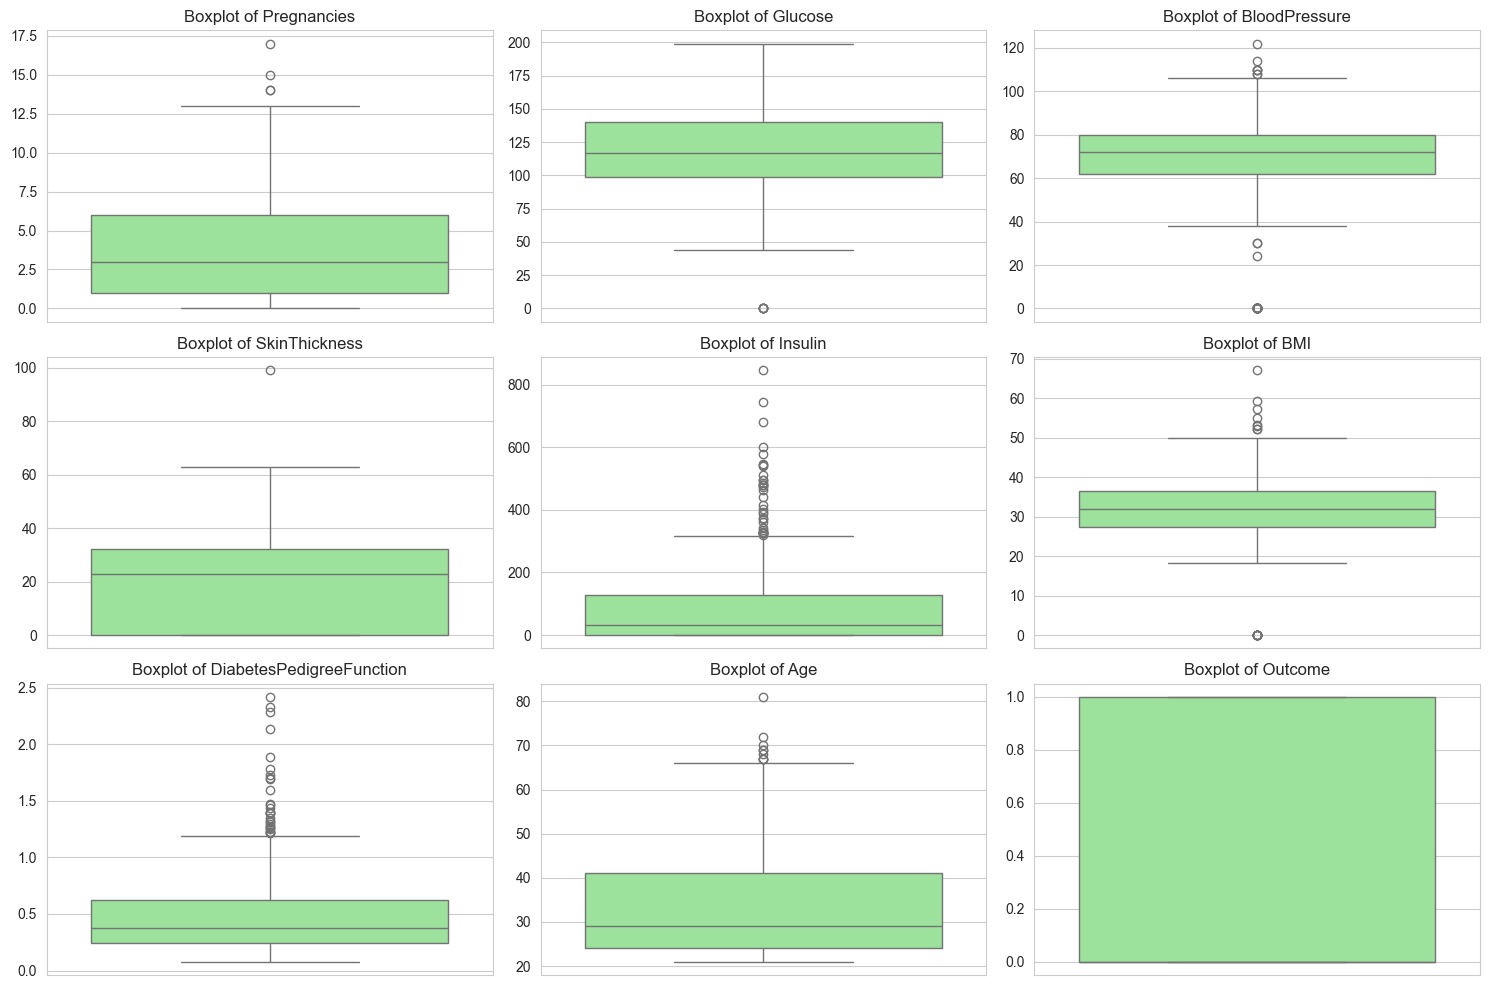

In [101]:
# 1. Set the plot size
plt.figure(figsize=(15, 10))

# 2. Loop through all columns to create a boxplot for each
for i, col in enumerate(df.columns, 1):
    plt.subplot(3, 3, i) # 3 rows, 3 columns
    
    # Create the boxplot
    sns.boxplot(y=df[col], color='lightgreen')
    
    # Add titles
    plt.title(f'Boxplot of {col}')
    plt.ylabel('') # Remove redundant y-axis label to keep it clean

# 3. Clean layout and show
plt.tight_layout()
plt.show()


# DATA PREPROCESSING


In [102]:

def zero(n):
    zero_counts = {}
    for col in ZERO_COLS:
        n_zeros = (df[col] == 0).sum()
        pct = n_zeros / len(df) * 100
        zero_counts[col] = n_zeros
        print(f"  {col:30s}: {n_zeros:4d} zeros  ({pct:.1f}%)")


In [103]:
ZERO_COLS = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
zero(ZERO_COLS)

  Glucose                       :    5 zeros  (0.7%)
  BloodPressure                 :   35 zeros  (4.6%)
  SkinThickness                 :  227 zeros  (29.6%)
  Insulin                       :  374 zeros  (48.7%)
  BMI                           :   11 zeros  (1.4%)


this 0 is basically the missing vlaue in this 

1 step ( FIXING THE MISSING 0 VALUE)

In [104]:
# The columns where zero is biologically impossible
ZERO_COLS = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# 1. Replace all zeros with actual NaN (Not a Number)
df[ZERO_COLS] = df[ZERO_COLS].replace(0,np.nan)

# Let's verify they converted to NaN correctly
print("Count of NaNs after replacing zeros:")
print(df[ZERO_COLS].isnull().sum())


Count of NaNs after replacing zeros:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


This is actually the right tool for the job here. Sklearn's imputers don't support group-aware imputation natively, so forcing it through sklearn just adds complexity for no benefit.




In [105]:
# 2. Fill the NaNs with the median value of that column
for col in ZERO_COLS:
    df[col]=df.groupby('Outcome')[col].transform(lambda x:x.fillna(x.median()))
    
# 3. Double-check that all NaNs are gone
print("Count of NaNs after grouping & filling:")
print(df[ZERO_COLS].isna().sum())


Count of NaNs after grouping & filling:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


# INSTEAD WE CAN DO THIS 
from sklearn.impute import SimpleImputer

//Replace zeros with NaN first (your step 1 stays the same)
df[ZERO_COLS] = df[ZERO_COLS].replace(0, np.nan)

//SimpleImputer fills with global median — no group awareness
imputer = SimpleImputer(strategy="median")
df[ZERO_COLS] = imputer.fit_transform(df[ZERO_COLS])

2 fixing outlier using Interquartile Range (IQR)

In [106]:
def cap_outliers_iqr(df,column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound  = Q1 - 1.5 *IQR
    upper_bound = Q3 + 1.5 * IQR

    # cap the values
    df[column] = np.where(df[column] > upper_bound, upper_bound,
                 np.where(df[column] < lower_bound, lower_bound, df[column]))

    return df

    # Example usage for a feature with outliers:
# df = cap_outliers_iqr(df, 'Insulin')
# df = cap_outliers_iqr(df, 'BMI')





In [107]:
# Example usage for a feature with outliers:
df = cap_outliers_iqr(df, 'Insulin')
df = cap_outliers_iqr(df, 'BMI')
df = cap_outliers_iqr(df, 'DiabetesPedigreeFunction')

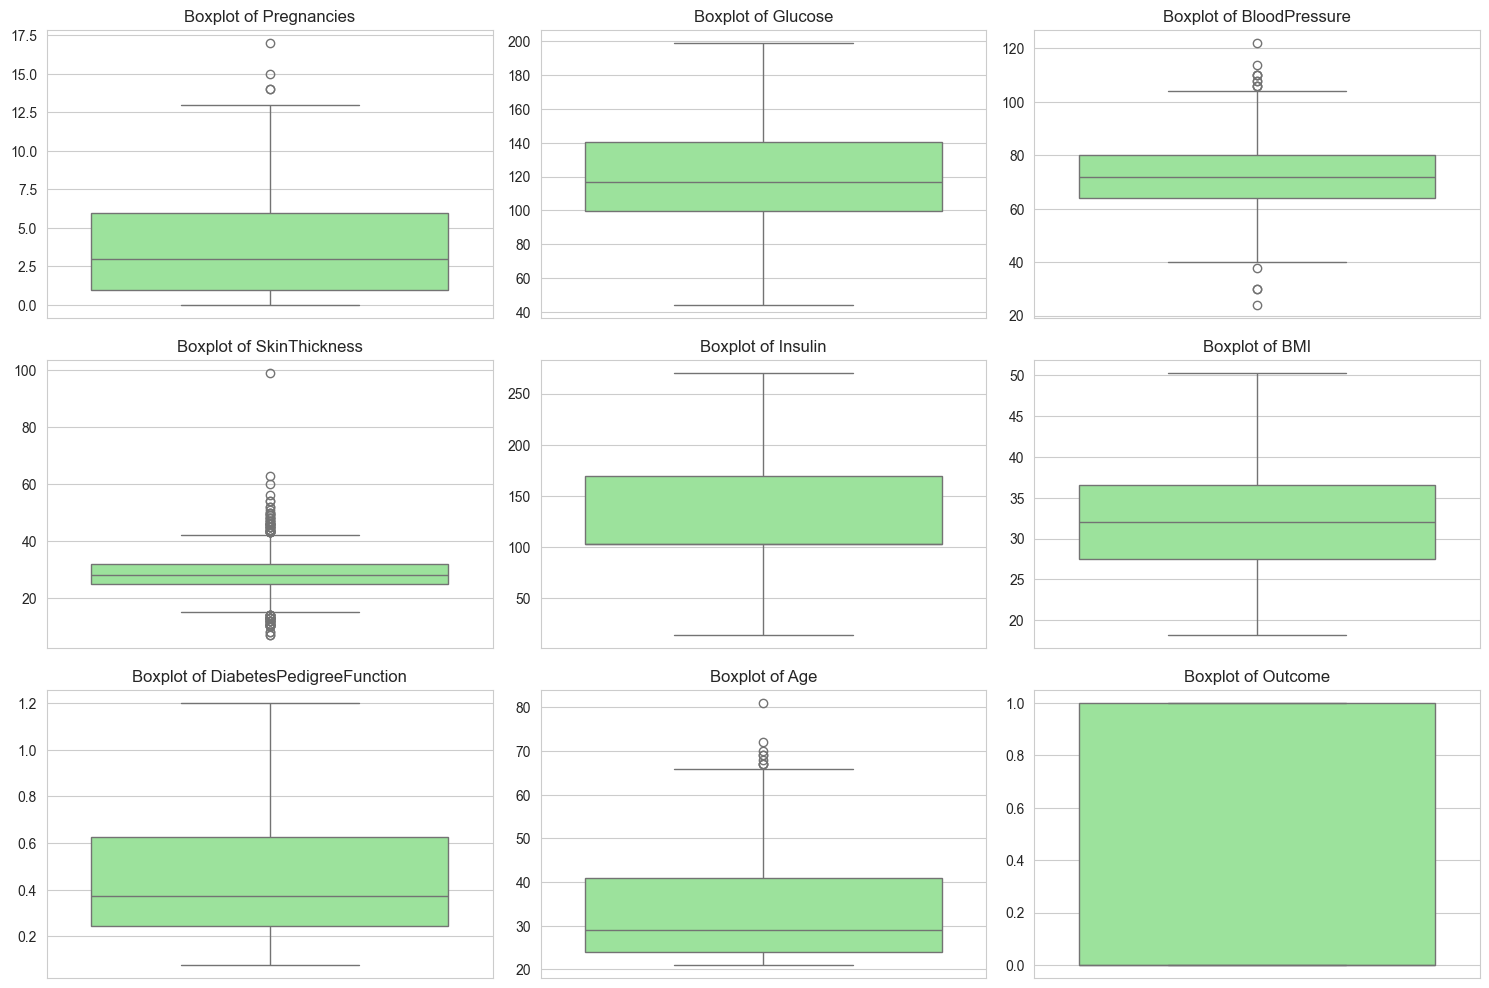

In [108]:
# 1. Set the plot size
plt.figure(figsize=(15, 10))

# 2. Loop through all columns to create a boxplot for each
for i, col in enumerate(df.columns, 1):
    plt.subplot(3, 3, i) # 3 rows, 3 columns
    
    # Create the boxplot
    sns.boxplot(y=df[col], color='lightgreen')
    
    # Add titles
    plt.title(f'Boxplot of {col}')
    plt.ylabel('') # Remove redundant y-axis label to keep it clean

# 3. Clean layout and show
plt.tight_layout()
plt.show()

In [109]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,1.200,33,1


# lets train the model ( without any tuner)

In [110]:
X = df.drop(columns=["Outcome"])   # all features, no target
y = df["Outcome"]  

In [111]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,random_state=1,test_size=0.2)

# SCALING VALUE

In [112]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)                          # learn mean & std from train only

X_train = scaler.transform(X_train)         # apply to train
X_test  = scaler.transform(X_test)          # apply to test using train's stats

In [155]:
import tensorflow 
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Dropout

In [114]:
model = Sequential()
model.add(Dense(32,activation='relu',input_dim=8))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='Adam' , loss='binary_crossentropy',metrics=['accuracy'])

In [115]:
model.fit(X_train, y_train, batch_size=32, epochs=100, validation_data=(X_test, y_test))


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6873 - loss: 0.5942 - val_accuracy: 0.7403 - val_loss: 0.5544
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7524 - loss: 0.5286 - val_accuracy: 0.8052 - val_loss: 0.4970
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7752 - loss: 0.4894 - val_accuracy: 0.8247 - val_loss: 0.4622
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7932 - loss: 0.4647 - val_accuracy: 0.8442 - val_loss: 0.4382
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8062 - loss: 0.4478 - val_accuracy: 0.8442 - val_loss: 0.4210
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8111 - loss: 0.4369 - val_accuracy: 0.8506 - val_loss: 0.4089
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8176 - loss: 0.4288 - val_accuracy: 0.8506 - val_loss: 0.4001
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8160 - loss: 0.4220 - val_accuracy: 0.8506 - 

# TUNING


-> HOW TO SELECT APPROPRIATE OPTIMIZER 

-> number of  in a layer 

->  select best number of layers

-> ALL in all one model 

In [116]:
import keras_tuner as kt

# 1) LET FIND THE BEST OPTIMIZER 

In [132]:
def build_model(hp):
    model = Sequential()
    model.add(Dense(32, activation="relu", input_dim=8))
    model.add(Dense(1, activation="sigmoid"))

    # ✅ define optimizer first, then compile
    optimizer = hp.Choice("optimizer", values=["adam", "sgd", "rmsprop", "adagrad"])

    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

In [133]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    directory = 'tuner_file',
    project_name='tuner_optimizer'
    
)


In [134]:
tuner.search(X_train, y_train, epochs=20, validation_data=(X_test, y_test))

Trial 4 Complete [00h 00m 07s]
val_accuracy: 0.8571428656578064

Best val_accuracy So Far: 0.8636363744735718
Total elapsed time: 00h 00m 29s


In [135]:
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best optimizer:", best_hp.get('optimizer'))

Best optimizer: sgd


In [136]:
model = tuner.get_best_models(num_models=1)[0]


In [137]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [138]:
model.fit(X_train,y_train,batch_size=32,epochs=1000,initial_epoch=21)

Epoch 22/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8241 - loss: 0.4363   
Epoch 23/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8257 - loss: 0.4334 
Epoch 24/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8257 - loss: 0.4308 
Epoch 25/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8274 - loss: 0.4284 
Epoch 26/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8306 - loss: 0.4262 
Epoch 27/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8257 - loss: 0.4242 
Epoch 28/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8274 - loss: 0.4222
Epoch 29/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8241 - loss: 0.4201 
Epoch 30/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8257 - loss: 0.4182
Epoch 31/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8274 - loss: 0.4164 
Epoch 32/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8290 - loss: 0.4147 
Epoch 33/1000
20/20 ━━━━━━━━━━━━

# 2) find the best number of epochs

In [144]:
def build_model(hp):
    model = Sequential()
    units = hp.Int('units', min_value=8, max_value=128)# we can add steps too but defaulty it jump to 1
    model.add(Dense(units=units, activation='relu', input_dim=8))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    directory='tuner_file2',
    project_name='tuner_units'
)

#
tuner.search(X_train, y_train, epochs=20, validation_data=(X_test, y_test))

# Now you can get the best parameters
best_param = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best units:", best_param.get('units'))


Trial 5 Complete [00h 00m 06s]
val_accuracy: 0.8441558480262756

Best val_accuracy So Far: 0.850649356842041
Total elapsed time: 00h 00m 32s
Best units: 87


In [145]:
model = tuner.get_best_models(num_models=1)[0]

In [146]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 87)             │           783 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            88 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 871 (3.40 KB)

 Trainable params: 871 (3.40 KB)

 Non-trainable params: 0 (0.00 B)

In [147]:
model.fit(X_train,y_train ,batch_size=32,epochs=1000,initial_epoch=21)

Epoch 22/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7964 - loss: 0.4461  
Epoch 23/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7997 - loss: 0.4428 
Epoch 24/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7997 - loss: 0.4398 
Epoch 25/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8062 - loss: 0.4370 
Epoch 26/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8062 - loss: 0.4346 
Epoch 27/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8062 - loss: 0.4322 
Epoch 28/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8062 - loss: 0.4299 
Epoch 29/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8029 - loss: 0.4280 
Epoch 30/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8062 - loss: 0.4261 
Epoch 31/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8062 - loss: 0.4243 
Epoch 32/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8078 - loss: 0.4225 
Epoch 33/1000
20/20 ━━━━━━━━━━━

# 3) FIND BEST NUMBER OF LAYERS

what we find till now 

-> BEST UNIT = 87
-> BEST OPTIMIZER = sqd

In [148]:
def build_model(hp):
    model = Sequential()

    model.add(Dense(units=87,activation='relu',input_dim=8))

    # for best layers
    for i in range(hp.Int('num_layers',min_value=1,max_value=10)):# min and max value mean it will try different model and try each layer in this range
        model.add(Dense(87,activation='relu'))
    
    model.add(Dense(1,activation='sigmoid'))

    model.compile(optimizer='sgd' , loss='binary_crossentropy' , metrics=['accuracy'])

    return model

tuner = kt.RandomSearch(build_model , objective='val_accuracy' , max_trials=5 , directory='tuner_file3' , project_name='tuner_layer')

tuner.search(X_train,y_train , epochs=20 , validation_data=(X_test,y_test))

best_param = tuner.get_best_hyperparameters(num_trials=1)[0]
print("best_param",best_param.get('num_layers'))


Trial 5 Complete [00h 00m 08s]
val_accuracy: 0.8311688303947449

Best val_accuracy So Far: 0.8311688303947449
Total elapsed time: 00h 00m 42s
best_param 4


In [149]:
model = tuner.get_best_models(num_models=1)[0]


In [150]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 87)             │           783 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 87)             │         7,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 87)             │         7,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 87)             │         7,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 87)             │         7,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            88 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,495 (123.03 KB)

 Trainable params: 31,495 (123.03 KB)

 Non-trainable params: 0 (0.00 B)

In [151]:
model.fit(X_train , y_train ,batch_size=32, epochs=1000,initial_epoch=21)

Epoch 22/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7866 - loss: 0.4597   
Epoch 23/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7948 - loss: 0.4498
Epoch 24/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8094 - loss: 0.4410
Epoch 25/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8078 - loss: 0.4323
Epoch 26/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8192 - loss: 0.4254
Epoch 27/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8225 - loss: 0.4184
Epoch 28/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8192 - loss: 0.4129
Epoch 29/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8225 - loss: 0.4079
Epoch 30/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8192 - loss: 0.4032
Epoch 31/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8241 - loss: 0.3991
Epoch 32/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8225 - loss: 0.3952
Epoch 33/1000
20/20 ━━━━━━━━━━━━━━━━━━━━

# NOW FINALIZE 

1) optimizer 
2) node
3) layers
4) activation
5) drop_out
6) learning_rate
7) batch size

In [173]:
import keras_tuner as kt
from keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, Adagrad


In [174]:
def build_model(hp):
    model = Sequential()

    for i in range(hp.Int('num_layers', min_value=1, max_value=10)):
        if i == 0:
            model.add(Dense(
                units=hp.Int('units'+str(i), min_value=8, max_value=128),
                activation=hp.Choice('activation'+str(i), values=['relu','tanh','sigmoid']),
                input_dim=8
            ))
            model.add(Dropout(hp.Choice('dropout'+str(i), values=[0.1, 0.2, 0.3, 0.4])))
        else:
            model.add(Dense(
                units=hp.Int('units'+str(i), min_value=8, max_value=128),
                activation=hp.Choice('activation'+str(i), values=['relu','tanh','sigmoid'])
            ))
            model.add(Dropout(hp.Choice('dropout'+str(i), values=[0.1, 0.2, 0.3, 0.4])))

        

    model.add(Dense(1, activation='sigmoid'))

    optimizer_name = hp.Choice('optimizer', values=['adam', 'sgd', 'rmsprop', 'adagrad'])
    lr = hp.Float('learning_rate', min_value=1e-4, max_value=1e-1, sampling='log')
    optimizers = {'adam': Adam(lr), 'sgd': SGD(lr), 'rmsprop': RMSprop(lr), 'adagrad': Adagrad(lr)}

    model.compile(optimizer=optimizers[optimizer_name], loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [175]:
tuner = kt.RandomSearch(build_model , objective='val_accuracy' , max_trials=5 , directory='tuner_file4',project_name='tuner_all',overwrite=True )

In [176]:
tuner.search(X_train , y_train , epochs=20 , validation_data=(X_test , y_test))

Trial 5 Complete [00h 00m 08s]
val_accuracy: 0.701298713684082

Best val_accuracy So Far: 0.850649356842041
Total elapsed time: 00h 00m 48s


In [177]:
tuner.get_best_hyperparameters(num_trials=1)[0].values


{'num_layers': 1,
 'units0': 58,
 'activation0': 'relu',
 'dropout0': 0.4,
 'optimizer': 'adam',
 'learning_rate': 0.0003021915685516182,
 'units1': 49,
 'activation1': 'sigmoid',
 'dropout1': 0.3,
 'units2': 126,
 'activation2': 'sigmoid',
 'dropout2': 0.1,
 'units3': 12,
 'activation3': 'sigmoid',
 'dropout3': 0.3,
 'units4': 69,
 'activation4': 'sigmoid',
 'dropout4': 0.3,
 'units5': 54,
 'activation5': 'sigmoid',
 'dropout5': 0.3,
 'units6': 83,
 'activation6': 'sigmoid',
 'dropout6': 0.1}

In [178]:
model = tuner.get_best_models(num_models=1)[0]

In [179]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 58)             │           522 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 58)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            59 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 581 (2.27 KB)

 Trainable params: 581 (2.27 KB)

 Non-trainable params: 0 (0.00 B)

In [181]:
history = model.fit(X_train , y_train , epochs=1000 , validation_data=(X_test,y_test) , initial_epoch = 21)

Epoch 22/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8876 - loss: 0.2877 - val_accuracy: 0.8896 - val_loss: 0.3347
Epoch 23/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8893 - loss: 0.2883 - val_accuracy: 0.8896 - val_loss: 0.3352
Epoch 24/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8876 - loss: 0.2989 - val_accuracy: 0.8896 - val_loss: 0.3349
Epoch 25/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8925 - loss: 0.2862 - val_accuracy: 0.8896 - val_loss: 0.3342
Epoch 26/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8876 - loss: 0.3154 - val_accuracy: 0.8896 - val_loss: 0.3340
Epoch 27/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8958 - loss: 0.2862 - val_accuracy: 0.8896 - val_loss: 0.3337
Epoch 28/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8974 - loss: 0.2851 - val_accuracy: 0.8896 - val_loss: 0.3342
Epoch 29/1000
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8941 - loss: 0.2798 - val_accu

# How to read the plots for overfitting:
Situation                 TrainAccuracy              Val Accuracy              


✅ Good fit            High                         Close to train


❌ Overfitting          High                        Much lower than train       


❌ Underfitting         Low                            Low (both bad)

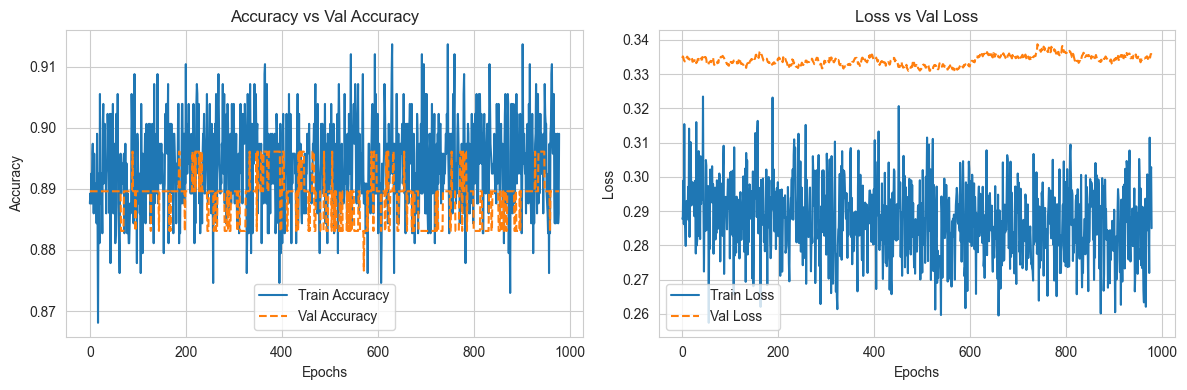

In [182]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# ── Plot 1: Accuracy ──────────────────────────────────────────────────────
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"],     label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy", linestyle="--")
plt.title("Accuracy vs Val Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# ── Plot 2: Loss ──────────────────────────────────────────────────────────
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"],     label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss", linestyle="--")
plt.title("Loss vs Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()